In [2]:
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(42)

KHAI BÁO DỮ LIỆU 

In [3]:
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

SIGMOID


### 1. Hàm 'sigmoid'
- Hàm này đưa ra một giá trị bất kỳ về từ khoảng 0 đến 1,dùng để biểu diễn xác suất dự đoán


### 2. Hàm 'logistic_sigmoid_regression'
- Hàm này dùng để huấn luyện mô hình với các tham số chính : 
X: Ma trận dữ liệu đầu vào 
y: vector nhãn 
w_init: trọng số khởi tạo ban đầu 
eta: learning rate
tol: ngưỡng kiểm tra hội tụ 
max_count: số lần cập nhật tối đa

- 'zi' là giá trị dự đoán của mô hình cho mẫu 'xi' qua hàm 'sigmoid'
- Cập nhật trọng số dựa trên ý tưởng: mô hình dự đoán chưa đúng thì điều chỉnh trọng số dựa trên sai lệch giữa nhãn thật 'yi' và nhãn dự đoán 'zi'
- Đến khi chuẩn Euclid giữa trọng số mới và trọng số vài bước trước < tol thì cố thể cho dừng xem như là gần hội tụ 

In [4]:
def sigmoid(s):
    return 1/(1+np.exp(-s))
def logistic_sigmoid_regression(X,y,w_init,eta,tol=1e-4,max_count=10000) :
    w=[w_init]
    it=0
    N=X.shape[1]
    d=X.shape[0]
    count=0
    check_w_after=20
    while count<max_count:
        mix_id=np.random.permutation(N)
        for i in mix_id:
            xi=X[:,i].reshape(d,1)
            yi=y[i]
            zi=sigmoid(np.dot(w[-1].T,xi))
            w_new=w[-1] +eta*(yi-zi)*xi
            count +=1
            if count %check_w_after ==0:
                if np.linalg.norm(w_new-w[-check_w_after])<tol:
                    return w
            w.append(w_new)
    return w
eta=.05
d=X.shape[0]
w_init=np.random.randn(d,1)

w=logistic_sigmoid_regression(X,y,w_init,eta)
display(w[-1])

array([[-4.07402882],
       [ 1.62295903]])

In [5]:
print(sigmoid(np.dot(w[-1].T, X)))

[[0.03687855 0.05433039 0.07936035 0.11452511 0.16252082 0.22550821
  0.22550821 0.30404469 0.39594953 0.49584229 0.59606808 0.6888714
  0.76862938 0.83290092 0.91817516 0.94393508 0.96192164 0.97429495
  0.98271986 0.99224972]]


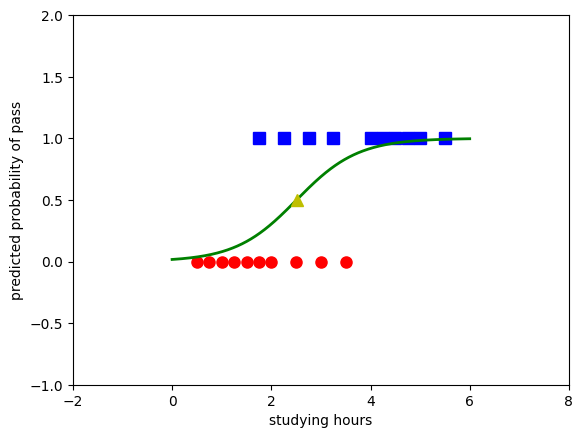

In [6]:
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

VIZUALIZATION:

Biểu đồ gồm 3 phần:

### 1. Các điểm dữ liệu 

- Đỏ: trượt
- Xanh: đậu 
### 2. Đường sigmoid

-Xác suất đậu theo số giờ học

### 3. Ngưỡng phân loại 

-Điểm mà xác suất đậu là 50%